In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_moons
import numpy as np
from tqdm import tqdm
from IPython.display import clear_output

from cccaatl_ml.core.tensor import Tensor, enable_autograd
import cccaatl_ml.core.layer as nn
import cccaatl_ml.core.losses as L 
import cccaatl_ml.core.activations as F 
import cccaatl_ml.core.dataloader as data

enable_autograd()

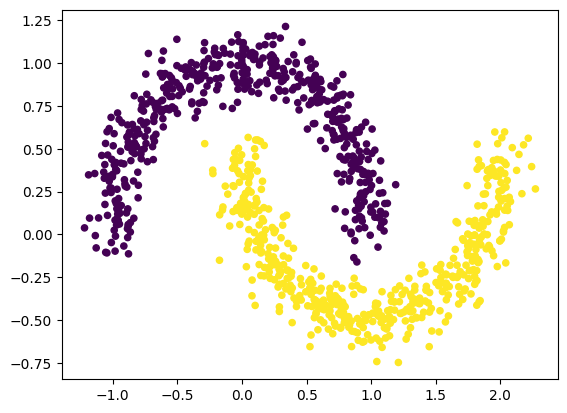

In [3]:
X, Y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X = Tensor(X.astype(np.float32), requires_grad=True)
Y = Tensor(Y.astype(np.int32))
plt.scatter(X._array[:, 0], X._array[:,1], c=Y._array, cmap='viridis', s=20)
plt.show()

In [4]:
# create Dataset from the moon dataset and pass it to Dataloader
dataset = data.TensorDataset(X, Y)
loader = data.DataLoader(dataset, batch_size=4, shuffle=True)
batch_X, batch_Y = next(iter(loader))

In [5]:
def get_decision_surface(model, x_min, x_max, y_min, y_max, resolution=100):
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    probs = []
    
    for pt in grid_points:
        inputs = Tensor(pt)
        pred = model(inputs)
        probs.append(pred._array[1])
        
    zz = np.array(probs).reshape(xx.shape)
    return xx, yy, zz
    
def plot_decision_surface(xx, yy, zz):
    plt.figure(figsize=(8, 6))
    
    contour = plt.contourf(xx, yy, zz, levels=50, cmap="RdBu", alpha=0.6)
    plt.colorbar(contour, label="Probability of Class 1")
    
    # 4. Superimpose the actual data points (using original labels Y)
    plt.scatter(X._array[:, 0], X._array[:, 1], c=Y._array, cmap="RdBu", edgecolors="black", linewidth=1.5, s=50)
    
    # 5. Draw the explicit 50% decision boundary line
    plt.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=2, linestyles="dashed")
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Model Predictions Superimposed on Data")
    plt.show()
    
def one_hot(x: Tensor, num_classes): 
    assert x._array.ndim == 1
    result = np.eye(num_classes)[x._array] 
    return Tensor(result, requires_grad=x.requires_grad)

In [6]:
class SGDOptimizer(object): 
    def __init__(self, model_params, step_size): 
        self.model_params = model_params
        self.step_size = step_size

    def zero_grad(self): 
        for param in self.model_params: 
            param.zero_grad()

    def step(self): 
        for param in self.model_params: 
            param._array = param._array - self.step_size * param.grad


In [7]:
MLP = nn.Sequential( 
    [
        nn.Linear(2, 32), 
        F.ReLU(), 
        nn.Linear(32, 32), 
        F.ReLU(), 
        nn.Linear(32,2)
    ]
)
[param._array for param in MLP.parameters()]

[array([[ 1.59060664, -0.07090577, -0.55073886,  0.9682428 ,  0.76346823,
          0.52261509, -0.10469935,  0.01703241, -0.55768978,  0.22023137,
         -0.22987553, -1.60108474,  0.67545069,  2.15418171,  0.29396868,
          0.1722237 , -0.33665208,  0.13031805, -0.38307998, -0.10261874,
         -0.37481859, -0.79231211,  0.21123291,  1.17806292, -0.35078295,
         -0.4012484 , -0.63467713,  0.6727195 , -0.3255204 , -0.00690771,
          0.27853687, -0.68015718],
        [ 0.21907925, -1.00595132, -0.0138102 , -0.12669901, -0.85435284,
          0.21277026,  0.43174535, -0.21844062, -0.44057574,  0.66234135,
          0.35575892, -1.1505997 ,  0.37985788,  0.01146547,  0.63928229,
         -0.27146644,  0.58150288, -1.10067525,  1.73852589,  1.63254638,
         -0.19951167, -0.26139114, -0.18548912,  0.1788606 ,  1.24067282,
          0.21151235, -0.23159479,  0.40559399, -0.35635458,  0.2066173 ,
         -1.29474102,  0.229908  ]]),
 array([ 1.3833523 ,  1.30296115, -0.9

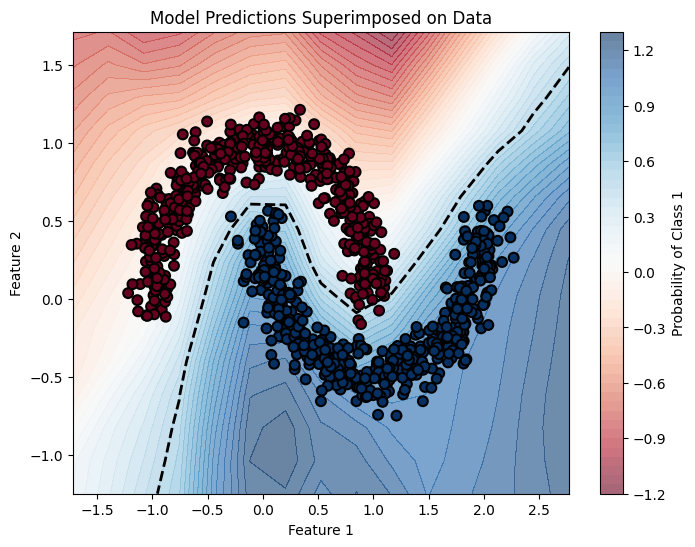

epoch: 99 loss: 0.00: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:00<00:00, 1939.83it/s]


In [11]:
# training loop 
optim = SGDOptimizer(MLP.parameters(), 1e-3)
epochs = 500
loss_fn = L.MSELoss()
losses = []

x_min, x_max = X._array[:, 0].min() - 0.5, X._array[:, 0].max() + 0.5
y_min, y_max = X._array[:, 1].min() - 0.5, X._array[:, 1].max() + 0.5
resolution = 15

for epoch in range(epochs): 
    clear_output(wait=True)
    xx, yy, zz = get_decision_surface(MLP, x_min, x_max, y_min, y_max, resolution=resolution)
    plot_decision_surface(xx, yy, zz,)
    
    pbar = tqdm(loader)
    for batch in pbar: 
        batch_X, batch_Y = batch
        batch_Y_onehot = one_hot(batch_Y, 2)
        optim.zero_grad()
        pred = MLP(batch_X)
        loss = loss_fn(pred, batch_Y_onehot)
        loss.backward() 
        losses.append(loss)
        optim.step()

        pbar.set_description(f"epoch: {epoch} loss: {loss._array:.2f}")

